In [99]:
# Install required libraries
!pip install pyspark
!pip install findspark
!pip install seaborn

In [100]:
# Import libraries
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
spark = SparkSession.builder \
    .appName("GlobalSuperstore_BigData_Analysis") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.0.2


In [104]:
from google.colab import files
uploaded = files.upload()

Saving Global_Superstore2.csv to Global_Superstore2 (1).csv


In [106]:
df = spark.read.csv(
    "/content/Global_Superstore2 (1).csv",
    header=True,
    inferSchema=True
)

In [107]:
df.printSchema()

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Market: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- Discount: string (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Shipping Cost: double (nullable = true)
 |-- Order Priority: string (nullable = true)



In [108]:
df.show(5)

+------+---------------+----------+----------+------------+-----------+----------------+-----------+-------------+---------------+-------------+-----------+------+-------+----------------+----------+------------+--------------------+--------+--------+--------+--------+-------------+--------------+
|Row ID|       Order ID|Order Date| Ship Date|   Ship Mode|Customer ID|   Customer Name|    Segment|         City|          State|      Country|Postal Code|Market| Region|      Product ID|  Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|Shipping Cost|Order Priority|
+------+---------------+----------+----------+------------+-----------+----------------+-----------+-------------+---------------+-------------+-----------+------+-------+----------------+----------+------------+--------------------+--------+--------+--------+--------+-------------+--------------+
| 32298| CA-2012-124891|31-07-2012|31-07-2012|    Same Day|   RH-19495|     Rick Hansen|   Consumer|New

In [109]:
df.columns

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'City',
 'State',
 'Country',
 'Postal Code',
 'Market',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping Cost',
 'Order Priority']

In [110]:
df.count()

51290

In [111]:
df.describe().show()

+-------+------------------+------------+----------+----------+--------------+-----------+------------------+-----------+--------------------+------+-----------+----------------+------+------+----------------+----------+------------+--------------------+------------------+------------------+-------------------+-----------------+------------------+------------------+
|summary|            Row ID|    Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|     Customer Name|    Segment|                City| State|    Country|     Postal Code|Market|Region|      Product ID|  Category|Sub-Category|        Product Name|             Sales|          Quantity|           Discount|           Profit|     Shipping Cost|    Order Priority|
+-------+------------------+------------+----------+----------+--------------+-----------+------------------+-----------+--------------------+------+-----------+----------------+------+------+----------------+----------+------------+--------------------+--------

In [112]:
from pyspark.sql.functions import col, count, when

missing_values = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing_values.show()

+------+--------+----------+---------+---------+-----------+-------------+-------+----+-----+-------+-----------+------+------+----------+--------+------------+------------+-----+--------+--------+------+-------------+--------------+
|Row ID|Order ID|Order Date|Ship Date|Ship Mode|Customer ID|Customer Name|Segment|City|State|Country|Postal Code|Market|Region|Product ID|Category|Sub-Category|Product Name|Sales|Quantity|Discount|Profit|Shipping Cost|Order Priority|
+------+--------+----------+---------+---------+-----------+-------------+-------+----+-----+-------+-----------+------+------+----------+--------+------------+------------+-----+--------+--------+------+-------------+--------------+
|     0|       0|         0|        0|        0|          0|            0|      0|   0|    0|      0|      41296|     0|     0|         0|       0|           0|           0|    0|       0|       0|     0|            0|             0|
+------+--------+----------+---------+---------+-----------+----

In [113]:
duplicate_count = df.count() - df.dropDuplicates().count()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [114]:
df = df.dropDuplicates()

In [115]:
df = df.dropna()

In [116]:
df = df.withColumn(
    "Order Date",
    to_date(col("Order Date"), "dd-MM-yyyy")
)

df = df.withColumn(
    "Ship Date",
    to_date(col("Ship Date"), "dd-MM-yyyy")
)

In [117]:
df.printSchema()

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Market: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- Discount: string (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Shipping Cost: double (nullable = true)
 |-- Order Priority: string (nullable = true)



In [118]:
df.filter(~col("Sales").rlike("^[0-9.]+$")).show(10, False)

+------+--------------+----------+----------+--------------+-----------+----------------+-----------+--------------+----------+-------------+-----------+------+------+---------------+---------------+------------+------------------------------------------------------------+--------------------+--------+--------+------+-------------+--------------+
|Row ID|Order ID      |Order Date|Ship Date |Ship Mode     |Customer ID|Customer Name   |Segment    |City          |State     |Country      |Postal Code|Market|Region|Product ID     |Category       |Sub-Category|Product Name                                                |Sales               |Quantity|Discount|Profit|Shipping Cost|Order Priority|
+------+--------------+----------+----------+--------------+-----------+----------------+-----------+--------------+----------+-------------+-----------+------+------+---------------+---------------+------------+------------------------------------------------------------+--------------------+--------

In [119]:
from pyspark.sql.functions import col

df = df.withColumn(
    "Sales",
    col("Sales").cast("double")
)

In [120]:
df = df.filter(col("Sales").isNotNull())

In [121]:
df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", True) \
    .csv("Global_Superstore2.csv")

In [122]:
df.printSchema()

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Market: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Shipping Cost: double (nullable = true)
 |-- Order Priority: string (nullable = true)



In [123]:
from pyspark.sql.functions import expr

df = df.withColumn(
    "Sales",
    expr("try_cast(Sales as double)")
)

df = df.filter(df.Sales.isNotNull())

In [124]:
from pyspark.sql.functions import sum, desc

sales_category = df.groupBy("Category") \
    .agg(sum("Sales").alias("Total_Sales")) \
    .orderBy(desc("Total_Sales"))

sales_category.show()

+---------------+------------------+
|       Category|       Total_Sales|
+---------------+------------------+
|     Technology| 4744557.498080019|
|      Furniture|  4110874.18629997|
|Office Supplies|3787070.2254999117|
+---------------+------------------+



In [125]:
duplicate_count = df.count() - df.dropDuplicates().count()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [126]:
df = df.dropDuplicates()

In [127]:
df = df.dropna()

In [128]:
df = df.withColumn(
    "Order Date",
    to_date(col("Order Date"), "dd-MM-yyyy")
)

df = df.withColumn(
    "Ship Date",
    to_date(col("Ship Date"), "dd-MM-yyyy")
)

In [129]:
sales_category = df.groupBy("Category") \
    .agg(sum("Sales").alias("Total_Sales")) \
    .orderBy(desc("Total_Sales"))

sales_category.show()

+---------------+-----------------+
|       Category|      Total_Sales|
+---------------+-----------------+
|     Technology|836154.0329999984|
|      Furniture|741999.7953000006|
|Office Supplies|719047.0320000018|
+---------------+-----------------+



In [130]:
profit_region = df.groupBy("Region") \
    .agg(sum("Profit").alias("Total_Profit")) \
    .orderBy(desc("Total_Profit"))

profit_region.show()

+-------+-----------------+
| Region|     Total_Profit|
+-------+-----------------+
|   West|108418.4488999999|
|   East|91522.78000000004|
|  South|46749.43030000001|
|Central|39706.36250000003|
+-------+-----------------+



In [131]:
top_products = df.groupBy("Product Name") \
    .agg(sum("Sales").alias("Total_Sales")) \
    .orderBy(desc("Total_Sales")) \
    .limit(10)

top_products.show()

+--------------------+------------------+
|        Product Name|       Total_Sales|
+--------------------+------------------+
|Canon imageCLASS ...|         61599.824|
|Fellowes PB500 El...|         27453.384|
|Cisco TelePresenc...|          22638.48|
|HON 5400 Series T...|         21870.576|
|GBC DocuBind TL30...|         19823.479|
|GBC Ibimaster 500...|           19024.5|
|Hewlett Packard L...|         18839.686|
|HP Designjet T520...|         18374.895|
|GBC DocuBind P400...|         17965.068|
|High Speed Automa...|17030.311999999998|
+--------------------+------------------+



In [132]:
sales_market = df.groupBy("Market") \
    .agg(sum("Sales").alias("Total_Sales")) \
    .orderBy(desc("Total_Sales"))

sales_market.show()

+------+-----------------+
|Market|      Total_Sales|
+------+-----------------+
|    US|2297200.860299985|
+------+-----------------+



In [133]:
segment_sales = df.groupBy("Segment") \
    .agg(sum("Sales").alias("Total_Sales"))

segment_sales.show()

+-----------+-----------------+
|    Segment|      Total_Sales|
+-----------+-----------------+
|  Corporate|706146.3667999997|
|Home Office|429653.1484999998|
|   Consumer|1161401.344999997|
+-----------+-----------------+



In [134]:
discount_category = df.groupBy("Category") \
    .agg(avg("Discount").alias("Avg_Discount"))

discount_category.show()

+---------------+-------------------+
|       Category|       Avg_Discount|
+---------------+-------------------+
|Office Supplies|0.15728509790905787|
|     Technology|  0.132322685435843|
|      Furniture|0.17392267798208327|
+---------------+-------------------+



In [135]:
shipping_cost = df.groupBy("Ship Mode") \
    .agg(avg("Shipping Cost").alias("Avg_Shipping"))

shipping_cost.show()

+--------------+------------------+
|     Ship Mode|      Avg_Shipping|
+--------------+------------------+
|  Second Class|28.285861182519294|
|Standard Class|17.671672252010783|
|   First Class| 35.56884265279583|
|      Same Day|42.335856353591176|
+--------------+------------------+



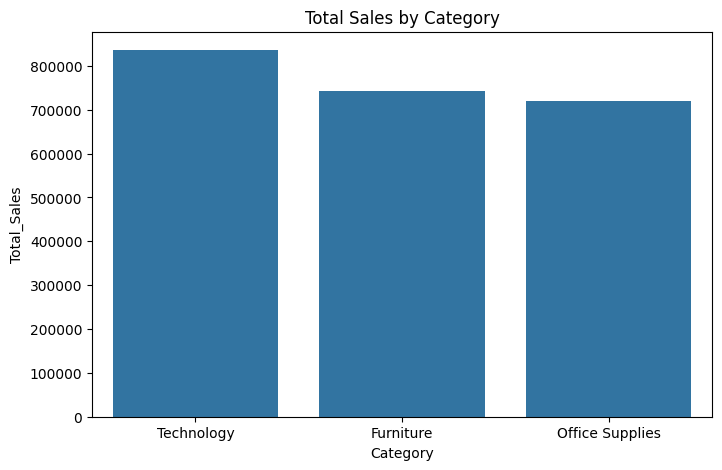

In [136]:
sales_pd = sales_category.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=sales_pd, x="Category", y="Total_Sales")
plt.title("Total Sales by Category")
plt.show()

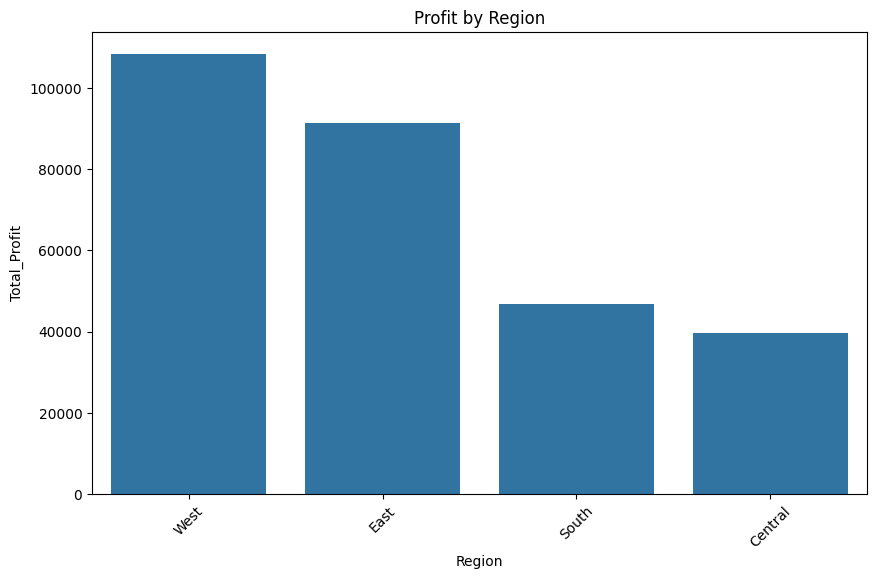

In [137]:
profit_pd = profit_region.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=profit_pd, x="Region", y="Total_Profit")
plt.xticks(rotation=45)
plt.title("Profit by Region")
plt.show()

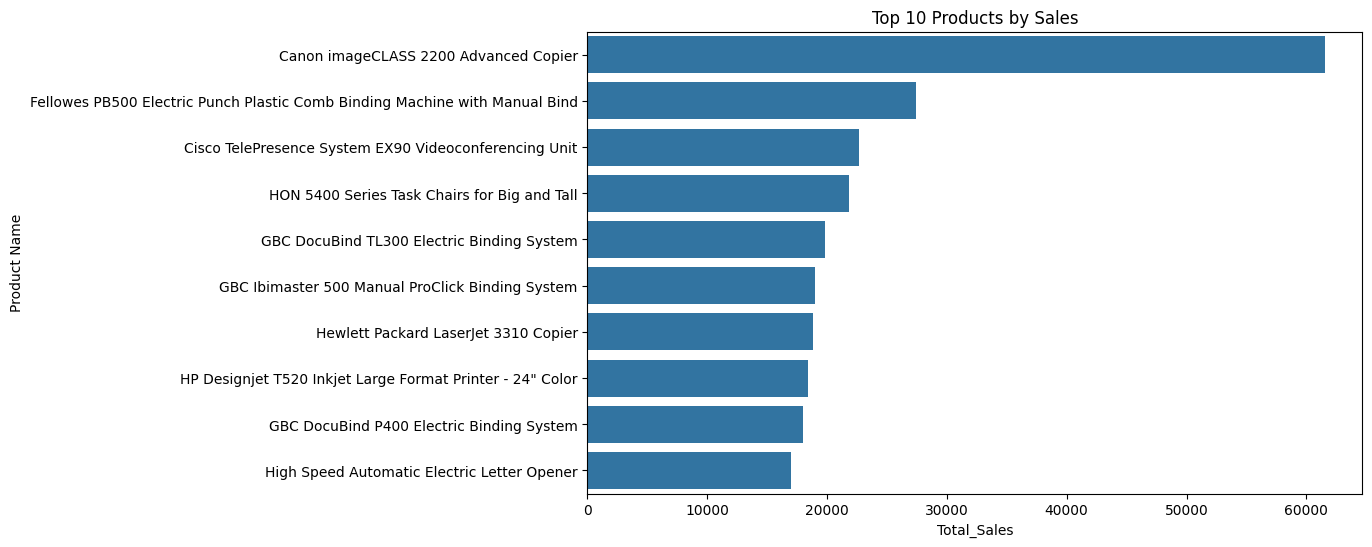

In [138]:
products_pd = top_products.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=products_pd, x="Total_Sales", y="Product Name")
plt.title("Top 10 Products by Sales")
plt.show()

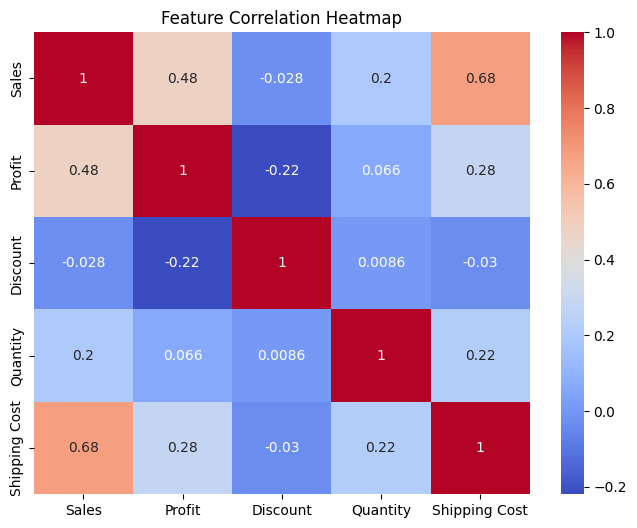

In [139]:
numeric_df = df.select("Sales","Profit","Discount","Quantity","Shipping Cost")

numeric_pd = numeric_df.toPandas()

plt.figure(figsize=(8,6))
sns.heatmap(numeric_pd.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()